# Ансамблирование с датасетом по сердечным заболеваниям

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import r2_score
from sklearn.model_selection import ShuffleSplit

## Attribute Information

- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]






## Loading dataset

In [3]:
import kagglehub

# Download latest version
data = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

path = "/root/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1"

# Загружаем данные
data = pd.read_csv(f"{path}/heart.csv")

# Показываем первые строки
print(data.head())

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


## Category preparing


In [4]:
from sklearn.preprocessing import LabelEncoder

# Копируем данные для преобразования
df = data.copy()

# Создаем LabelEncoder для категориальных признаков
label_encoders = {}

# Список категориальных колонок
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Применяем LabelEncoder к каждой категориальной колонке
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Категориальные переменные преобразованы в цифровые")
print(df.head())

Категориальные переменные преобразованы в цифровые
   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40    1              1        140          289          0           1   
1   49    0              2        160          180          0           1   
2   37    1              1        130          283          0           2   
3   48    0              0        138          214          0           1   
4   54    1              2        150          195          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0    172               0      0.0         2             0  
1    156               0      1.0         1             1  
2     98               0      0.0         2             0  
3    108               1      1.5         1             1  
4    122               0      0.0         2             0  


## Data visualization

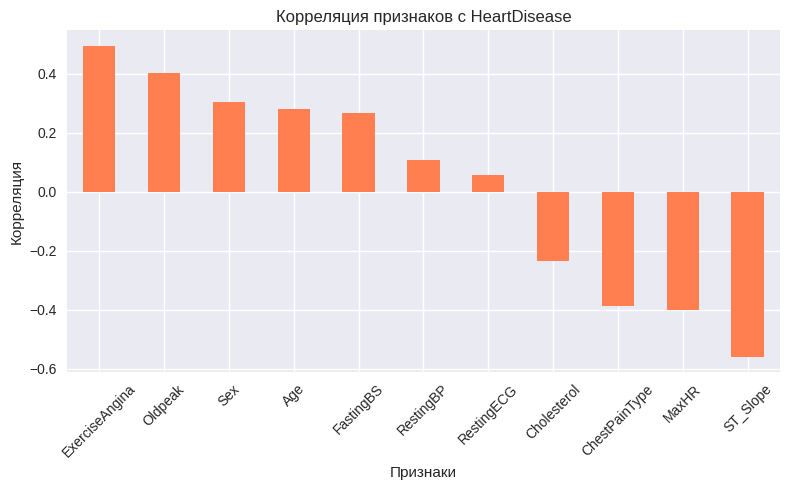

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
plt.style.use('seaborn-v0_8')

# Корреляция признаков с сердечными заболеваниями
plt.figure(figsize=(8, 5))
correlations = df.corr()['HeartDisease'].sort_values(ascending=False)[1:]
correlations.plot(kind='bar', color='coral')
plt.title('Корреляция признаков с HeartDisease')
plt.xlabel('Признаки')
plt.ylabel('Корреляция')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Dataset splitting

In [8]:
from sklearn.model_selection import train_test_split

# Разделяем признаки (X) и целевую переменную (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Разделение 80/20 с фиксированным random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # сохраняем пропорции классов
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"Признаков: {X_train.shape[1]}")

Обучающая выборка: 734 строк
Тестовая выборка: 184 строк
Признаков: 11


## Tree and ensemble tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# a) Дерево решений
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# b) Случайный лес
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Модели обучены:")
print(f"- DecisionTreeClassifier: {dt_model}")
print(f"- RandomForestClassifier: {rf_model}")

Модели обучены:
- DecisionTreeClassifier: DecisionTreeClassifier(random_state=42)
- RandomForestClassifier: RandomForestClassifier(random_state=42)


In [10]:
from sklearn.metrics import classification_report

# Предсказания для Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Предсказания для Random Forest
y_pred_rf = rf_model.predict(X_test)

# Метрики для Decision Tree
print("=" * 50)
print("DECISION TREE CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_dt))

# Метрики для Random Forest
print("\n" + "=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

DECISION TREE CLASSIFIER
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        82
           1       0.81      0.80      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



## Bagging

In [11]:
from sklearn.ensemble import BaggingClassifier

# Бэггинг над Decision Tree
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)

# Предсказания для бэггинга
y_pred_bagging = bagging_model.predict(X_test)

# Метрики для всех трех моделей
print("=" * 50)
print("DECISION TREE CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_dt))

print("\n" + "=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

print("\n" + "=" * 50)
print("BAGGING (over Decision Tree)")
print("=" * 50)
print(classification_report(y_test, y_pred_bagging))


DECISION TREE CLASSIFIER
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        82
           1       0.81      0.80      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184


BAGGING (over Decision Tree)
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87    

## Stacking

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import LinearSVC

# Создаем стек из трех моделей
stacking_model = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svm', LinearSVC(random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=42)
)

stacking_model.fit(X_train, y_train)

# Предсказания для стекинга
y_pred_stacking = stacking_model.predict(X_test)

# Метрики для всех четырех моделей
print("=" * 50)
print("DECISION TREE CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_dt))

print("\n" + "=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

print("\n" + "=" * 50)
print("BAGGING (over Decision Tree)")
print("=" * 50)
print(classification_report(y_test, y_pred_bagging))

print("\n" + "=" * 50)
print("STACKING (DT + RF + SVM)")
print("=" * 50)
print(classification_report(y_test, y_pred_stacking))


DECISION TREE CLASSIFIER
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        82
           1       0.81      0.80      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184


RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184


BAGGING (over Decision Tree)
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87    

## Conclusion
Наилучшая модель: RANDOM FOREST CLASSIFIER и также хорошо BAGGING (over Decision Tree)